# Data Mining Regression Project - Possum Regression

## Agampreet Bajaj

## What is our problem?
We are trying to predict the age of a possum given certain features of past possums by developing a regression model. Understanding the relationship between possum traits and age is important because it can be valuable for actuarial science teams. We can look at 2 problems here, try to identify what age of possums are overtaking the rest - if old, then there could be an underpopulation problem - vice versa. Or, later on, if the science teams look for disease control, we could help understand which ages are being taken out based on those features, but that would be a later implementation.

## What is the data?
The dataset comes from [Kaggle](https://www.kaggle.com/datasets/abrambeyer/openintro-possum) and it shows measurments and attributes of possums collected from southern Australia. It has many physical features: body length, tail length, foot length, total length, and many demographic features: sex, location, and our target age. This dataset suits my needs because of the explanatory variables, how they correlate with each other - which we will look at - and its source of a real Australian environmental journal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("possum.csv")
df
df_copy = df.copy()

In [3]:
df.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


### Stats to See:
From this chart, we can see that our possum's age ranges from 1 to 9. This is actually pretty interesting, as a possum's average age is about 4 years old. This means we could see some outlier possums. We see about 2 missing values in age and one in foot length. The case column looks to be the same as an ID placement, as we se the mean is the average of 1 to 104, and so are their quartile placements. One sneaky column is the site one, which is numerical in the dataset, but given the Kaggle description, it is a number given to each different site, meaning we will treat it like a categorical value. I thought it was ordinal, but realized there is no ranking of one site over another.

In [4]:
df.sum(numeric_only=True)

case        5460.0
site         377.0
age          391.0
hdlngth     9630.7
skullw      5915.9
totlngth    9057.2
taill       3849.0
footlgth    7051.3
earconch    5005.6
eye         1564.8
chest       2808.0
belly       3389.0
dtype: float64

In [5]:
df.isna().sum()

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [6]:
df[df['footlgth'].isna()]

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
40,41,2,Vic,f,5.0,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5


In [7]:
df[df['age'].isna()]

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
43,44,2,Vic,m,NaN,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0
45,46,2,Vic,m,NaN,91.4,54.4,84.0,35.0,72.8,51.2,14.4,24.5,35.0


## Null or Nah?
Judging by our sum of null values, the entire dataset seems to only have 3 rows in total that are null. 2 of them are from the age feature, and one is from the foot length feature. Normally, with null values being in the target variable, I would try and impute or figure out a way to handle it. But with only 3 rows empty in a large enough dataset, I will just drop these null rows instead.

In [8]:
df.isna().sum()
df = df.drop(columns=['case'])
df = df.dropna(subset=['footlgth'])
df = df.dropna(subset=['age'])

In [9]:
df.isna().sum()

site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64

## Visualization and Understanding

age
3.0    27
2.0    16
4.0    14
5.0    12
6.0    12
1.0    10
7.0     7
9.0     2
8.0     1
Name: count, dtype: int64


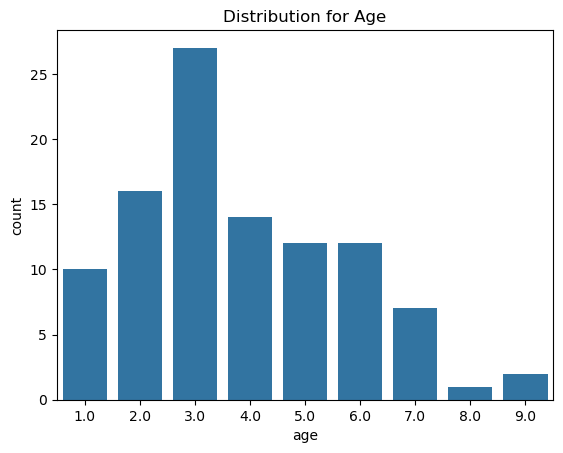

In [10]:
print(df['age'].value_counts())
sns.countplot(df, x='age')
plt.title("Distribution for Age")
plt.show()

In this graph, we can see that there are more possums age 3 than any other age, just like our ```python df.describe()``` code said. We now also see the count of our possums in their older age. When I search it up, possums normally live to 3-4 in the wild and 4-5 years old in sanctuary. This shows me that from count 6 and up, most of the posssums are not wild. With our model having a right-skew we just need to look out for the outlier values 8 and 9.

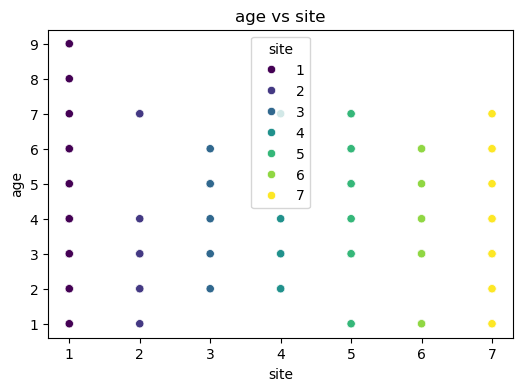

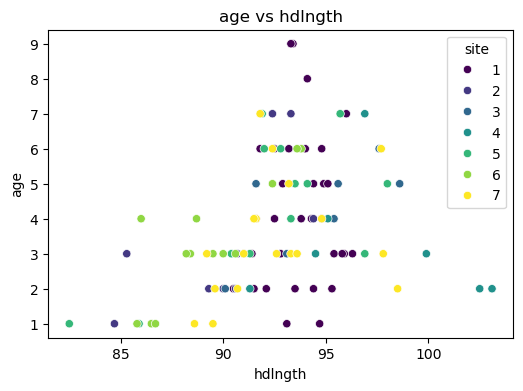

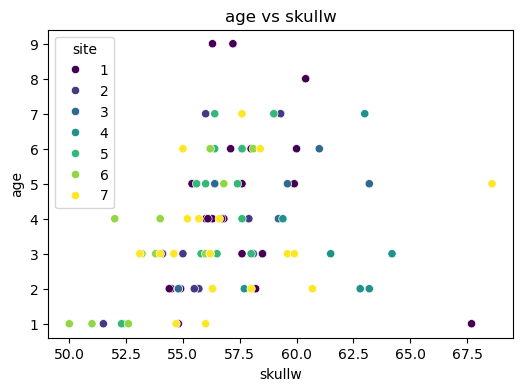

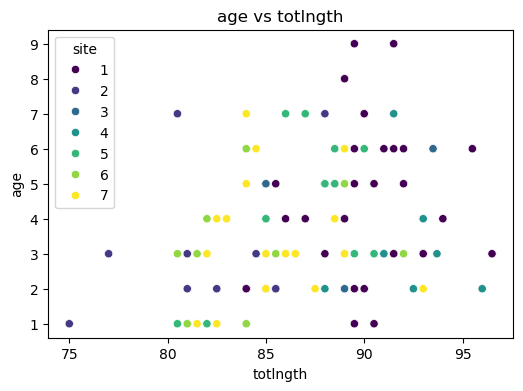

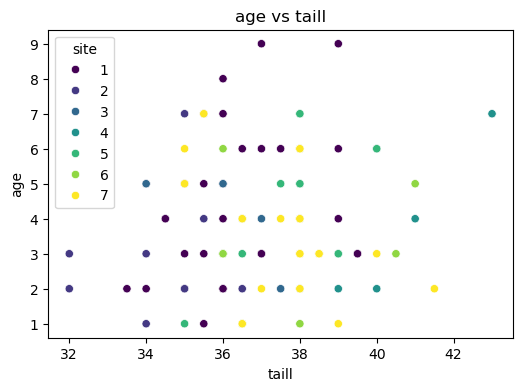

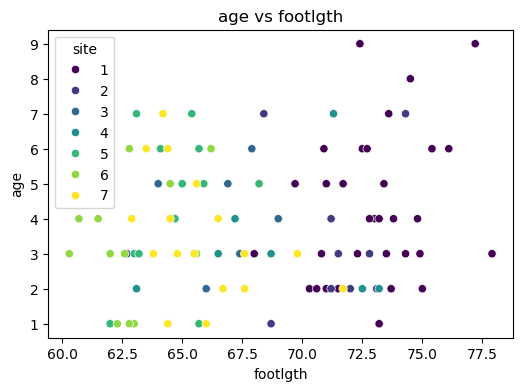

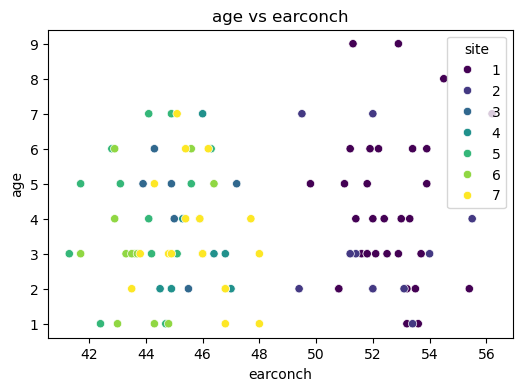

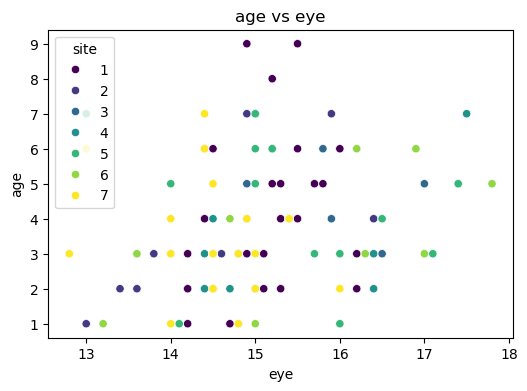

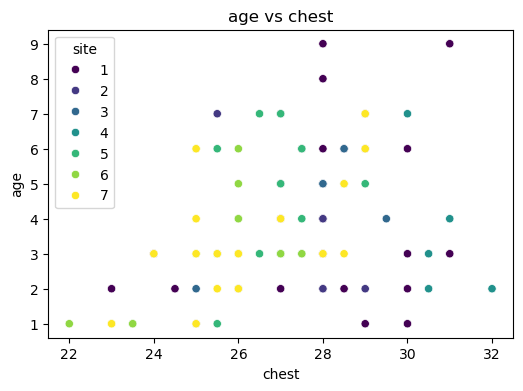

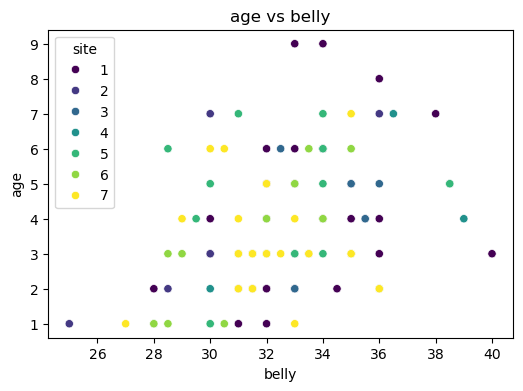

In [11]:
features = []

for col in df.select_dtypes(include='number').columns:
    if col != 'age':
        features.append(col)

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='age', hue='site', palette='viridis')
    plt.title(f'age vs {col}')
    plt.xlabel(col)
    plt.ylabel('age')
    plt.show()

Let's look at how our features correlate with the label by using sites as our hue. This means our site label is categorical, and we can see what sites have what possums. In age vs head length, there is a slight triangle from age 2 to 5, and between 90-95 mm in head length. This shows us that we won't see a lot of head change from a possum that is a child vs a mature one. Younger possums have slightly smaller heads, but some remain the same size. No size shows a clear pattern, so it is consistent between all regions.<br><br>In the age vs foot length, there is an upward pattern showing. Young possums from 1-3 age have shorter feet, at 60-68 mm. Older possums have 10 mm longer feet. From age 5 and up, there is not a lot of increase in the foot length, which also shows from the last visualization that the maturity of a possum here is about 4-5 years old. A lot of site 2's possums are showing longer feet, even if the age is 2 or 8, meaning this site might have some environmental features that help possums grow feet from a small age. Let's look at one more. <br><br> In age vs chest, smaller possums show a wide range of chest size, but this also shows that the chest size does not really change while growing up. A slight increase from 22-25 mm to 28-30 while growing up, but because of the number of 2-year-olds with varying chest size, I believe there could be some outlier/individual possums that are born genetically different (larger) than the rest. This doesn't mean we shouldn't use this feature, but we should probably check the correlations.

In [12]:
label = df['age']

for col in features:
    if col != 'age':
        corr = label.corr(df[col])
        print(f'{col}: {corr:.3f}')

site: -0.128
hdlngth: 0.330
skullw: 0.286
totlngth: 0.268
taill: 0.120
footlgth: 0.126
earconch: 0.066
eye: 0.232
chest: 0.335
belly: 0.361


We see that there is not a big correlation for some of our features, but because the dataste size is small and our features are important to a possum's body, we will keep them and use linear regression as a simple and linear model.

## Morphological Relationships
### We will look at the relationships between the biological traits of possums

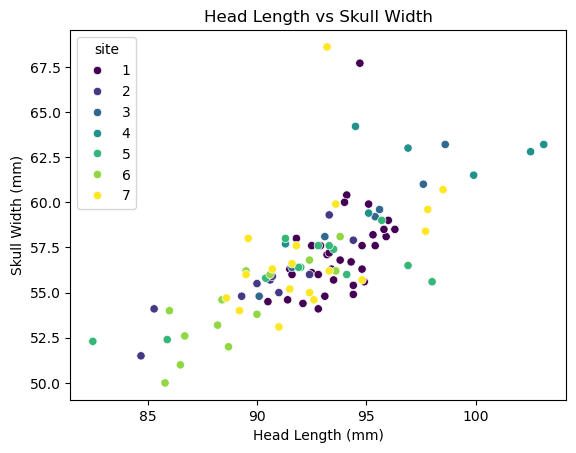

In [13]:
sns.scatterplot(data=df, x='hdlngth', y='skullw', hue='site', palette='viridis')
plt.title("Head Length vs Skull Width")
plt.xlabel("Head Length (mm)")
plt.ylabel("Skull Width (mm)")
plt.show()

### Head Length vs Skull Width on Possums

I wanted to graph the head length and skull width to understand how possums' skulls grow in relation to their head size. From the graph alone, we can see a clear linear relationship forming. As head length increases, so does skull width. Showing us that large-headed possums also exhibit larger skull cavities, which is a consistent biological relationship. They are all centered around head length 90-95 and skull width 53-60, showing that many possums have around the same correlation, except for some outliers in other regions. A lot of the sites are centered too, with small exceptions being 4, whose head lengths go up to 100 and higher, and up to 62.5 skull width. This can be a sign of individual possums being different rather than a group evolution.

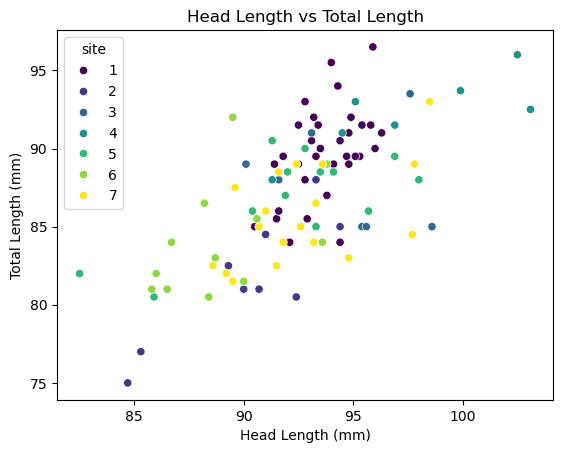

In [14]:
sns.scatterplot(data=df, x='hdlngth', y='totlngth', hue="site", palette='viridis')
plt.title("Head Length vs Total Length")
plt.xlabel("Head Length (mm)")
plt.ylabel("Total Length (mm)")
plt.show()

### Head Length vs Total Length on Possums

As the head length grows, so does the total length of a possum. We see the trend goes more upwards, and is more scattered than a simple linear fit. We do see a large cluster at 90-95 head length, where the body size is almost proportionate, 87-93. Each possum is more spread out, showing a large variation in total length, showing how, in nature, body diversity is seen in all species of possums. Sites 6-7 show more scatter than the rest, with both of them continuing a downwards run - more individuals with smaller bodies. We can assume that head length correlates strongly with total body length on possums, but not perfectly. Body length can depend on sex or environmental concerns at different sites.

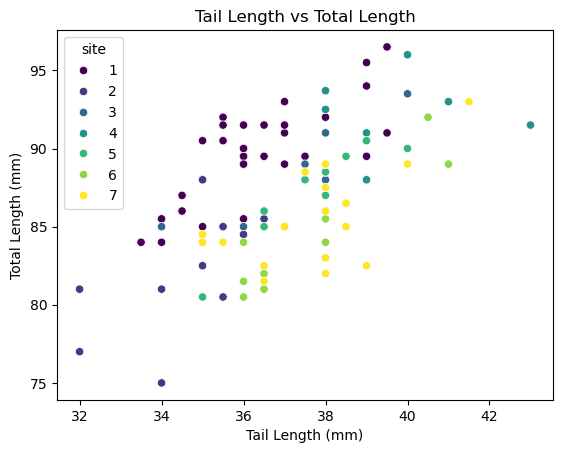

In [15]:
sns.scatterplot(data=df, x='taill', y='totlngth', hue="site", palette='viridis')
plt.title("Tail Length vs Total Length")
plt.xlabel("Tail Length (mm)")
plt.ylabel("Total Length (mm)")
plt.show()

### Tail Length vs Total Length on Possums

There is a clear positive correlation between tail length and total length of a possum. The longer the tail, the bigger the possum in this general trend. In a biological sense, this works, as the total length of a possum is encapsulated by its head, body, and tail, with tail length naturally contributing to the total length of a possum. There is a cluster between 35-40 tail length with 85-95 total length. We see some possums have similar traits (same tail lengths) but different total lengths, likely do to head size, from which environment they are from. Each site seems to be consistently varied, with some, like site 6, showing a smaller total length with a higher tail length. This makes sense with what we saw earlier with site 6 having a smaller body size and varying head size. We can assume tail length is a good indicator of the total body size, especially when combined with the other morphological features: head length and foot length.

## Pipeline Creation / GridSearch / Testing

In [16]:
y = df['age']
X = df.drop(columns=['age'])

cat_cols = ['site']
num_cols = df.select_dtypes(include='number').columns.difference(cat_cols).tolist()
num_cols.remove('age')
num_cols

['belly',
 'chest',
 'earconch',
 'eye',
 'footlgth',
 'hdlngth',
 'skullw',
 'taill',
 'totlngth']

In [17]:
preprocess = ColumnTransformer(transformers=[
                ('num', StandardScaler(), num_cols),
                ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
                ], remainder='drop')

X_trn, X_tst, y_trn, y_tst = train_test_split(X,y, test_size=0.2, random_state=42)

lin_reg_pip = Pipeline([
                ('prep', preprocess),
                ('model', LinearRegression())])

lin_reg_pip.fit(X_trn, y_trn)

pred = lin_reg_pip.predict(X_tst)

rmse = mean_squared_error(y_tst, pred) ** 0.5
mae = mean_absolute_error(y_tst, pred)
r2 = r2_score(y_tst, pred)

print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | r2: {r2:.3f}")

RMSE: 2.095 | MAE: 1.550 | r2: 0.030


In [18]:
cv_rmse = -cross_val_score(lin_reg_pip, X_trn, y_trn, scoring='neg_root_mean_squared_error', cv=5)
print(f"CV RMSE: Mean/STD -> {cv_rmse.mean():.3f} +- {cv_rmse.std():.3f}")

CV RMSE: Mean/STD -> 2.007 +- 0.390


In [19]:
grid = {'model' : [Ridge()],
        'model__alpha' : [0.01, 0.1, 1, 10]}

ridge_pip = Pipeline(
                [('prep', preprocess),
                 ('model', Ridge())])

gs = GridSearchCV(ridge_pip, grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=1)
gs.fit(X_trn, y_trn)

best = gs.best_estimator_
best_prd = best.predict(X_tst)
rmse_gs = mean_squared_error(y_tst, best_prd) ** 0.5
print(f"Best Params: {gs.best_params_}, RMSE: {rmse_gs:.3f}")

Best Params: {'model': Ridge(), 'model__alpha': 10}, RMSE: 2.026


### Linear/Ridge Regression:
My r2 value is extremely low, showing 0.03, but our RMSE is about 2. Given the r2 value, my linear model is showing almost no variance in the age label. The RMSE value shows an average error of 2 years, which is only a little bit better than the baseline. We can assume that the morphological measures that were collinear, have a non-linear relationship to the age label. Because of this, I am going to test out a Random Forest Regressor as it is a non-linear model can learn trends without manual work.

In [20]:
rf_pip = Pipeline(
            [('prep', preprocess),
             ('model', RandomForestRegressor(n_estimators=400, random_state=42))])
cv = -cross_val_score(rf_pip, X_trn, y_trn, cv=5, scoring='neg_root_mean_squared_error')
print(f"Random Forest RMSE: {cv.mean()} +- {cv.std()}")

Random Forest RMSE: 1.6979161027282526 +- 0.28964857797182714


In [21]:
rf_grid = { 'model__n_estimators' : [200,400], 
            'model__max_depth' : [None,6,14],
            'model__min_samples_leaf': [2, 4],
            'model__min_samples_split': [2, 4, 8],
            'model__max_features' : ['sqrt', 0.6],
            'model__bootstrap' : [True]}
rf_gs = GridSearchCV(rf_pip, rf_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=3, verbose=0)
rf_gs.fit(X_trn,y_trn)
print("Best params:", rf_gs.best_params_)
print("CV RMSE (mean):", -rf_gs.best_score_)

Best params: {'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
CV RMSE (mean): 1.658607608768709


In [22]:
rf_best = rf_gs.best_estimator_
rf_best.fit(X_trn, y_trn)
rf_pred = rf_best.predict(X_tst)

rf_rmse = mean_squared_error(y_tst, rf_pred) ** 0.5
rf_mae = mean_absolute_error(y_tst, rf_pred)
rf_r2 = r2_score(y_tst, rf_pred)

print(f"RMSE: {rf_rmse:.3f} | MAE: {rf_mae:.3f} | R²: {rf_r2:.3f}")

RMSE: 1.821 | MAE: 1.468 | R²: 0.267


### Random Forest Regressor:
This model's r2 value is 0.267, which is much better than the linear model's 0.030, and shows about 26% variance in possum age. This improvement shows that this model is capturing more non-linear relationships between the target label 'age' and our features. Our MAE is just a little from the previous 1.550, with a score of 1.468, which shows a consistent relationship without any external outliers. This model has a much better RMSE score of 1.821, which indicates that our predictions are about 1.8 years off the actual value. This is much better than 2 years off. Possum growth is working better with non-linear relationships, so tree-based models, just like this Random Forest, will be better than linear models.

## Impact
This project looks into possum features and predicts possum age from their measurments and environments. The ability to estimate age from different traits can help researchers and conservationists monitor wildlife populations efficiently, and can support ecological studies by making data collection faster. This model can help with identifying possum ages in different sites so researchers know about overpopulation problems, or if a disease is spreading, which age will be hurt the most. Negatively, getting enough data to create a model for sites worldwide will include a lot of invasive monitoring of possums, disrupting their environment. The model can have a good amount of bias, as there could be a lot of data coming from the same site or same species, which means generalizing to other locations and species might not be possible. Ethically, it is important to use the model responsibly, acknowledging uncertainty and trying to avoid relying on its predictions without biological validation.

## References

**Original Data:**  
Lindenmayer, D. B., Viggers, K. L., Cunningham, R. B., & Donnelly, C. F. (1995).  
_Morphological variation among columns of the mountain brushtail possum, Trichosurus caninus Ogilby (Phalangeridae: Marsupialia)._  
_Australian Journal of Zoology, 43_(4), 449–458.  
[https://doi.org/10.1071/ZO9950449](https://doi.org/10.1071/ZO9950449)

**Adapted Dataset Version:**  
Beyer, A. (2023). _OpenIntro Possum Dataset_.  
Available on [Kaggle](https://www.kaggle.com/datasets/abrambeyer/openintro-possum)
